# Import Libraries and implement logger

In [196]:
## IMPORT LIBRARIES

from sklearn. model_selection import train_test_split
from sklearn. preprocessing import MinMaxScaler
import logging
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from enum import Enum
from pathlib import Path
from io import StringIO
from datetime import datetime
from typing import Tuple, List, Optional, Dict
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

In [197]:
# CREATE LOGGER FOR JUPYTER NOTEBOOKS
def setup_logger():
    # Create logger instance
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    # Clear existing, avoid duplicate logs
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create FileHandler in overrite mode
    file_handler = logging.FileHandler('../../logmodeler.log', mode ='w')

    # Set format
    formatter = logging.Formatter('%(asctime)s - %(levelno)s - %(lineno)d - %(module)s - %(message)s')
    file_handler.setFormatter(formatter)

    # Add FileHandler to logger
    logger.addHandler(file_handler)

    return logger

logger = setup_logger()

# Inspcet the data read in after the Visualzer

In [198]:
## Define function for inspection
def inspect_raw_data(df, output_path=None):
    '''
    Inspect a DataFrame and save info to a text file.
    Parameters:
    df : pandas DataFrame
    output_path : Path or str, optional
        Where to save the output file. If None and save_to_file is True,
        will use current directory
    '''

    # Set display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Prepare the information
    info_text = []
    info_text.append(f"Generated on: {datetime.now()}")
    info_text.append(f"Shape: {df.shape}")
    
    # Get info in string format
    buffer = StringIO()
    df.info(buf=buffer)
    info_text.append(f"\nDataFrame Info:")
    info_text.append(buffer.getvalue())

    # Add first 5 rows
    buffer_head = StringIO()
    df.head().to_string(buf=buffer_head)
    info_text.append(f"\nFirst 5 rows:")
    info_text.append(buffer_head.getvalue())

    # Add last 5 rows
    buffer_tail = StringIO()
    df.tail().to_string(buf=buffer_tail)
    info_text.append(f"\nLast 5 rows:")
    info_text.append(buffer_tail.getvalue())
    
    # Join all information
    full_report = '\n'.join(info_text)
    output_path = Path(output_path)
    output_path.write_text(full_report)
    logger.info(f"Report saved to: {output_path}")
    
    return full_report

In [199]:
# READ IN
data_path_test = Path('..') / '..' / 'data' / 'processed' / 'Visualizer' / 'test'
data_path_eso = Path('..') / '..' / 'data' / 'processed' / 'Visualizer' / 'eso'
data_path_ger = Path('..') / '..' / 'data' / 'processed' / 'Visualizer' / 'ger'

# TEST 
X_train = pd.read_csv(data_path_test / 'X_train.csv', delimiter=',', parse_dates=['ID']) # fit_transformed
y_train = pd.read_csv(data_path_test / 'y_train.csv', delimiter=',', parse_dates=['ID']) 

X_eval = pd.read_csv(data_path_test / 'X_eval.csv', delimiter=',', parse_dates=['ID']) # transformed
y_eval = pd.read_csv(data_path_test/ 'y_eval.csv', delimiter=',', parse_dates=['ID']) 

# ESO
X_train_eso = pd.read_csv(data_path_eso / 'X_train_eso.csv', delimiter=',', parse_dates=['ID']) # fit_transformed
y_train_eso = pd.read_csv(data_path_eso / 'y_train_eso.csv', delimiter=',', parse_dates=['ID']) 

X_eval_eso = pd.read_csv(data_path_eso / 'X_eval_eso.csv', delimiter=',', parse_dates=['ID']) # transformed
y_eval_eso = pd.read_csv(data_path_eso / 'y_eval_eso.csv', delimiter=',', parse_dates=['ID']) 

# GER
X_train_ger = pd.read_csv(data_path_ger / 'X_train_ger.csv', delimiter=',', parse_dates=['ID']) # fit_transformed
y_train_ger = pd.read_csv(data_path_ger / 'y_train_ger.csv', delimiter=',', parse_dates=['ID']) 

X_eval_ger = pd.read_csv(data_path_ger / 'X_eval_ger.csv', delimiter=',', parse_dates=['ID']) # transformed
y_eval_ger = pd.read_csv(data_path_ger / 'y_eval_ger.csv', delimiter=',', parse_dates=['ID']) 

In [200]:
## SAVE FORE INSPECTION
data_path = Path('..') / '..' / 'data' / 'processed' 
# TEST
# fit_transformed
_ = inspect_raw_data(X_train, output_path=Path(f'{data_path}/Modeler/test/X_train.txt'))
_ = inspect_raw_data(y_train, output_path=Path(f'{data_path}/Modeler/test/y_train.txt'))
# transformed
_ = inspect_raw_data(X_eval, output_path=Path(f'{data_path}/Modeler/test/X_eval.txt'))
_ = inspect_raw_data(y_eval, output_path=Path(f'{data_path}/Modeler/test/y_eval.txt'))
# ESO
# fit_transformed
_ = inspect_raw_data(X_train_eso, output_path=Path(f'{data_path}/Modeler/eso/X_train_eso.txt'))
_ = inspect_raw_data(y_train_eso, output_path=Path(f'{data_path}/Modeler/eso/y_train_eso.txt'))
# transformed
_ = inspect_raw_data(X_eval_eso, output_path=Path(f'{data_path}/Modeler/eso/X_eval_eso.txt'))
_ = inspect_raw_data(y_eval_eso, output_path=Path(f'{data_path}/Modeler/eso/y_eval_eso.txt'))
# GER
# fit_transformed
_ = inspect_raw_data(X_train_ger, output_path=Path(f'{data_path}/Modeler/ger/X_train_ger.txt'))
_ = inspect_raw_data(y_train_ger, output_path=Path(f'{data_path}/Modeler/ger/y_train_ger.txt'))
# transformed
_ = inspect_raw_data(X_eval_ger, output_path=Path(f'{data_path}/Modeler/ger/X_eval_ger.txt'))
_ = inspect_raw_data(y_eval_ger, output_path=Path(f'{data_path}/Modeler/ger/y_eval_ger.txt'))

# Begin modeling after read in the dataframes 
#### Set requirements for building a predictor 
    - Use pytorch LSTM to predict the next value of the target into the future
      Consider: 
      https://pytorch.org/tutorials/beginner/nlp/sequence_models_tutorial.html, 
      https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html 
    - Use the already and normalized in read in dataframes X_train, y_train
    - Consider the information in the text files. the model should work with dynamical numbers of features. 
    - Use proper Evaluation Metric
    - Consider: batch size, epoche, learning rate, learning rate dk

In [201]:
import torch # to create tensors to store numerical values
import torch.nn # to make weight and bias tensors part of the neural network
import torch.nn.functional as F # for the activation function
from torch.optim import Adam # to fit the neural network to the data (similar to SGD, not quite as stochastic)
import lightning as L # training tool
from torch.utils.data import TensorDataset, DataLoader # to handle large datasets


Epoch [10/100], Loss: 0.0874
Epoch [20/100], Loss: 0.0862
Epoch [30/100], Loss: 0.0881
Epoch [40/100], Loss: 0.0868
Epoch [50/100], Loss: 0.0866
Epoch [60/100], Loss: 0.0884
Epoch [70/100], Loss: 0.0872
Epoch [80/100], Loss: 0.0879
Epoch [90/100], Loss: 0.0869
Epoch [100/100], Loss: 0.0876


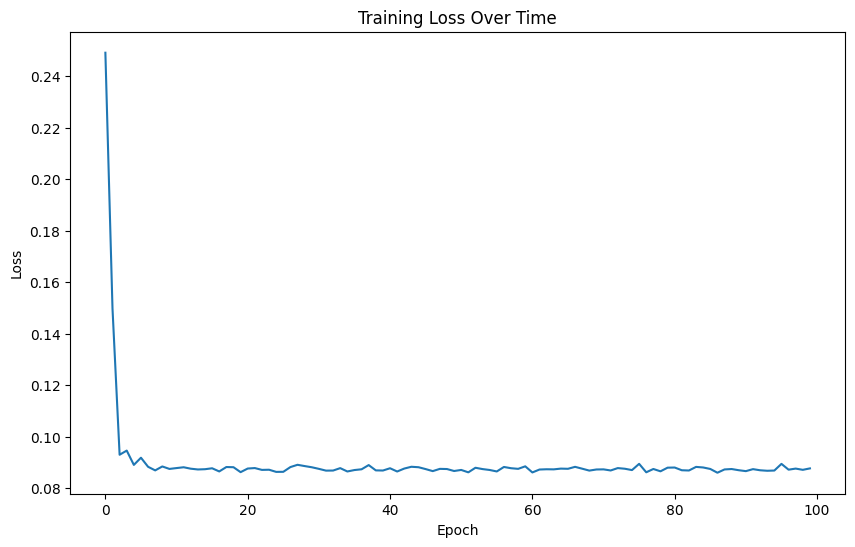

Predicted next value: 0.46


In [202]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, sequence_length=24):
        # Extract features (excluding ID column) and convert to numpy array
        self.X = torch.FloatTensor(X.select_dtypes(include=['float64']).values)
        self.y = torch.FloatTensor(y['FOSSIL'].values)
        self.sequence_length = sequence_length
        
    def __len__(self):
        return len(self.X) - self.sequence_length
        
    def __getitem__(self, idx):
        return (self.X[idx:idx + self.sequence_length],
                self.y[idx + self.sequence_length])

class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

def train_model(model, train_loader, criterion, optimizer, num_epochs, device):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets.unsqueeze(1))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')
    
    return train_losses

def train_lstm_model(X_train, y_train):
    # Model hyperparameters
    sequence_length = 24  # Number of time steps to look back
    batch_size = 32
    hidden_size = 64
    num_layers = 2
    num_epochs = 100
    learning_rate = 0.001
    
    # Create dataset and dataloader
    dataset = TimeSeriesDataset(X_train, y_train, sequence_length)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_size = len(X_train.select_dtypes(include=['float64']).columns)  # Number of features
    model = LSTMPredictor(input_size, hidden_size, num_layers).to(device)
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    losses = train_model(model, train_loader, criterion, optimizer, num_epochs, device)
    
    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()
    
    return model, dataset

def predict_next_value(model, dataset, device):
    model.eval()
    with torch.no_grad():
        last_sequence = dataset.X[-dataset.sequence_length:].unsqueeze(0).to(device)
        prediction = model(last_sequence)
        return prediction.item()

# Usage example:
model, dataset = train_lstm_model(X_train, y_train)
next_value = predict_next_value(model, dataset, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Predicted next value: {next_value:.2f}")

/usr/local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [10/200]
Train Loss: 0.0833, Val Loss: 0.1016
Training Metrics: {'MSE': 0.083323136, 'RMSE': 0.2886575, 'MAE': 0.25194475, 'R2': -0.004880797362154743}
Validation Metrics: {'MSE': 0.101597965, 'RMSE': 0.31874436, 'MAE': 0.28207394, 'R2': 0.002512339692054999}
Current Learning Rate: 0.001
--------------------------------------------------
Early stopping triggered at epoch 15


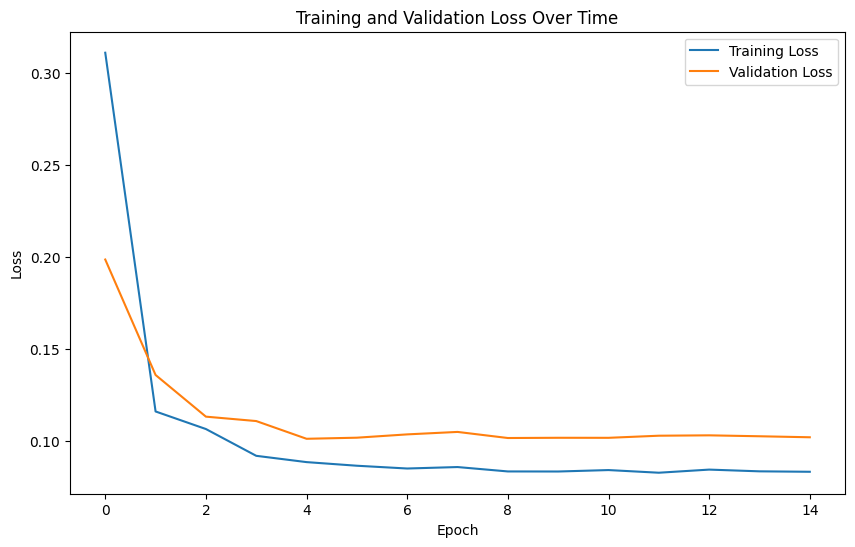

Predicted next value: 0.47

Prediction Analysis:
--------------------------------------------------
Predicted next value: 0.47

Last 5 actual values in the dataset:
Timestamp: 2017-04-03T05:00:00.000000000, Value: 0.41
Timestamp: 2017-04-01T07:00:00.000000000, Value: 0.18
Timestamp: 2017-04-02T22:00:00.000000000, Value: 0.77
Timestamp: 2017-04-04T17:30:00.000000000, Value: 0.14
Timestamp: 2017-04-03T03:00:00.000000000, Value: 0.32


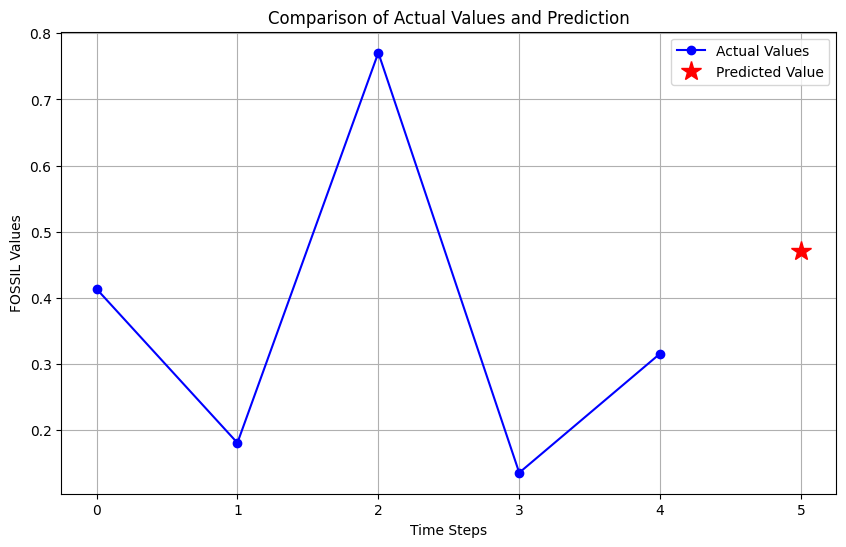

In [206]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, sequence_length=24):
        self.X = torch.FloatTensor(X.select_dtypes(include=['float64']).values)
        self.y = torch.FloatTensor(y['FOSSIL'].values)
        self.sequence_length = sequence_length
        
    def __len__(self):
        return len(self.X) - self.sequence_length
        
    def __getitem__(self, idx):
        return (self.X[idx:idx + self.sequence_length],
                self.y[idx + self.sequence_length])

class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

def evaluate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    model.train()
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_train_loss = 0.0
        train_predictions = []
        train_targets = []
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets.unsqueeze(1))
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            
            running_train_loss += loss.item()
            train_predictions.extend(outputs.cpu().detach().numpy())
            train_targets.extend(targets.cpu().numpy())
        
        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        
        # Validation phase
        model.eval()
        running_val_loss = 0.0
        val_predictions = []
        val_targets = []
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, targets.unsqueeze(1))
                
                running_val_loss += loss.item()
                val_predictions.extend(outputs.cpu().numpy())
                val_targets.extend(targets.cpu().numpy())
        
        epoch_val_loss = running_val_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        
        # Learning rate scheduling
        scheduler.step(epoch_val_loss)
        
        # Early stopping check
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
        if (epoch + 1) % 10 == 0:
            # Calculate metrics
            train_metrics = evaluate_metrics(train_targets, train_predictions)
            val_metrics = evaluate_metrics(val_targets, val_predictions)
            
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f"Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
            print("Training Metrics:", train_metrics)
            print("Validation Metrics:", val_metrics)
            print("Current Learning Rate:", optimizer.param_groups[0]['lr'])
            print("-" * 50)
    
    return train_losses, val_losses

def train_lstm_model(X_train, y_train):
    # Hyperparameters
    sequence_length = 24
    batch_size = 32  # Smaller batch size for better generalization
    hidden_size = 128  # Increased hidden size
    num_layers = 3  # Added another layer
    num_epochs = 200  # More epochs with early stopping
    learning_rate = 0.001
    
    # Create dataset
    dataset = TimeSeriesDataset(X_train, y_train, sequence_length)
    
    # Split into train and validation sets
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    input_size = len(X_train.select_dtypes(include=['float64']).columns)
    model = LSTMPredictor(input_size, hidden_size, num_layers).to(device)
    
    # Loss and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5, 
        verbose=True
    )
    
    # Train the model
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, 
        optimizer, scheduler, num_epochs, device
    )
    
    # Plot training and validation losses
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
    return model, dataset

def predict_next_value(model, dataset, device):
    model.eval()
    with torch.no_grad():
        last_sequence = dataset.X[-dataset.sequence_length:].unsqueeze(0).to(device)
        prediction = model(last_sequence)
        return prediction.item()

# Usage example:
model, dataset = train_lstm_model(X_train, y_train)
next_value = predict_next_value(model, dataset, torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"Predicted next value: {next_value:.2f}")

def predict_and_compare(model, X_train, y_train, sequence_length):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    with torch.no_grad():
        # Get the last sequence from X_train
        last_sequence = torch.FloatTensor(X_train.select_dtypes(include=['float64']).values[-sequence_length:])
        last_sequence = last_sequence.unsqueeze(0).to(device)
        
        # Make prediction
        prediction = model(last_sequence)
        predicted_value = prediction.item()
        
        # Get actual values for last few timestamps
        true_values = y_train['FOSSIL'].values[-5:]  # Get last 5 values for context
        timestamps = y_train['ID'].values[-5:]  # Get corresponding timestamps
        
        print("\nPrediction Analysis:")
        print("-" * 50)
        print(f"Predicted next value: {predicted_value:.2f}")
        print("\nLast 5 actual values in the dataset:")
        for ts, val in zip(timestamps, true_values):
            print(f"Timestamp: {ts}, Value: {val:.2f}")
        
        # Visualize the comparison
        plt.figure(figsize=(10, 6))
        plt.plot(range(len(true_values)), true_values, 'b-o', label='Actual Values')
        plt.plot(len(true_values), predicted_value, 'r*', label='Predicted Value', markersize=15)
        plt.title('Comparison of Actual Values and Prediction')
        plt.xlabel('Time Steps')
        plt.ylabel('FOSSIL Values')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        return predicted_value, true_values[-1]

# Now you can use it like this:
predicted_value, last_true_value = predict_and_compare(model, X_train, y_train, sequence_length=24)

